In [12]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
comparison=pd.read_csv(r"C:\Users\ASUS\OneDrive\Documents\ML Project\Smartwatches project\Dataset\Processed\comparison.csv")

X_train=pd.read_csv(r'C:\Users\ASUS\OneDrive\Documents\ML Project\Smartwatches project\Dataset\Processed\X_train.csv')
X_test=pd.read_csv(r'C:\Users\ASUS\OneDrive\Documents\ML Project\Smartwatches project\Dataset\Processed\X_test.csv')

y_test=comparison['Actual Ratings']
y_pred=comparison['Predicted Ratings']

In [4]:
y_pred

0     3.656954
1     4.081767
2     4.462357
3     4.148384
4     3.839423
        ...   
83    4.324933
84    4.279273
85    4.135717
86    4.075635
87    4.077955
Name: Predicted Ratings, Length: 88, dtype: float64

In [5]:
MAE=mean_absolute_error(y_test, y_pred)

MSE=mean_squared_error(y_test, y_pred)

R2=r2_score(y_test, y_pred)

RMSE=np.sqrt(MSE)

print('The MAE is:', MAE)
print('The MSE is:', MSE)
print('The R2 Score is:', R2)
print('The RMSE is:', RMSE)

The MAE is: 0.28178891929053923
The MSE is: 0.16688796419784954
The R2 Score is: 0.39658019817899914
The RMSE is: 0.4085192335715046


In [11]:
n = X_train.shape[0] # No. of test samples
p = X_train.shape[1] #No. of features

adjusted_r2 = 1 - ((1 - R2) * (n - 1) / (n - p - 1))
print('The Adjusted R2 square is: ', adjusted_r2)

The Adjusted R2 square is:  0.22449381025226922


## Observation:

- The relatively low Adjusted R² indicates that Linear Regression is unable to effectively utilize the large number of features. This suggests that the underlying relationship between the predictors and the target is likely non-linear.

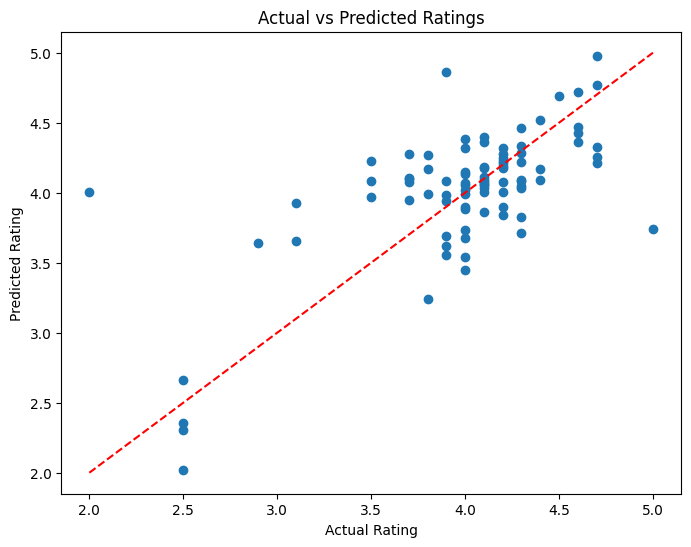

In [13]:

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.show()

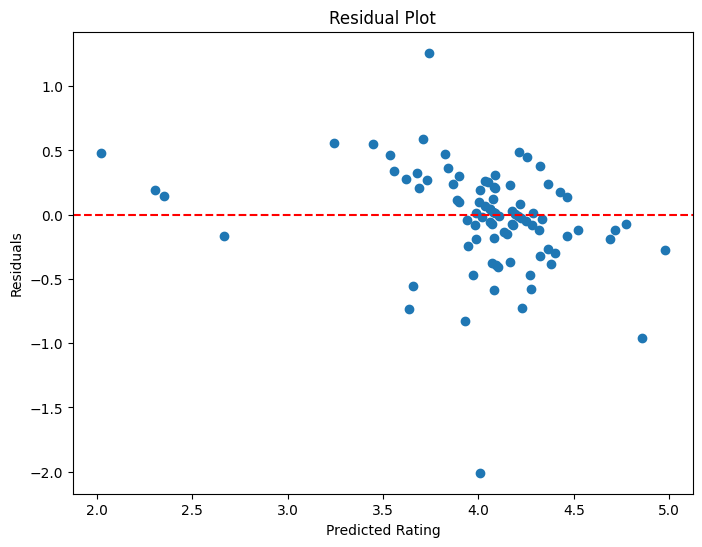

In [15]:
residuals=y_test-y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

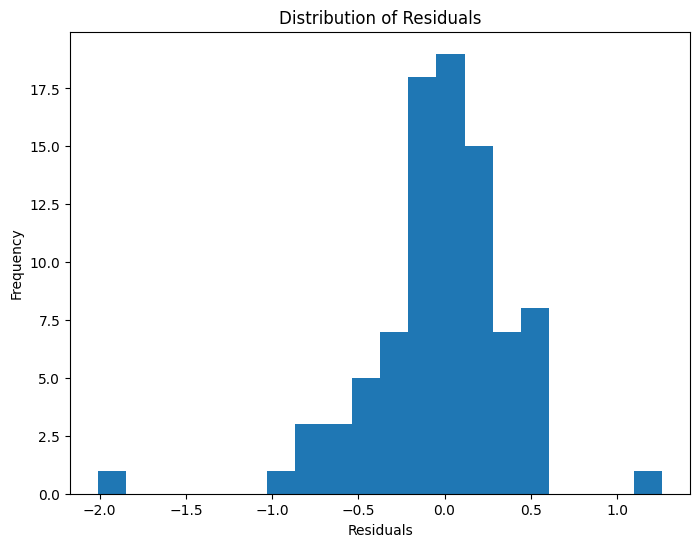

In [16]:
plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=20
)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

# Final Conclusion:

- Successfully built and trained a Linear Regression model to predict smartwatch ratings.
- Performed complete data preprocessing, including data cleaning, feature engineering, one-hot encoding, and feature scaling.
- The model achieved the following evaluation metrics:
    1. MAE: 0.2818
    2. MSE: 0.1669
    3. RMSE: 0.4085
    4. R² Score: 0.3966
    5. Adjusted R² Score: 0.2245
- The MAE of 0.2818 indicates that the model predicts smartwatch ratings with an average error of approximately 0.28 rating points.
- The RMSE of 0.4085 suggests that a few observations have relatively larger prediction errors, as RMSE penalizes large errors more than MAE.
- The R² Score of 39.66% shows that the model explains a moderate portion of the variability in smartwatch ratings.
- The Adjusted R² Score decreased to 22.45%, indicating that several of the input features contribute little additional predictive information after accounting for model complexity.
- The Actual vs Predicted and Residual plots show that the model captures the general trend of the data but still exhibits noticeable prediction errors for some products.
- Customer ratings are influenced by several subjective factors (such as user experience, product quality, comfort, and customer satisfaction) that are not available in the dataset, limiting the performance of a linear model.
- Overall, Linear Regression serves as a good baseline model, but its performance suggests that the relationship between the input features and smartwatch ratings is not entirely linear.
- Therefore, more advanced machine learning algorithms such as Decision Tree Regression, Random Forest Regression, Gradient Boosting, and XGBoost will be explored and compared to determine whether they provide better predictive performance on this dataset.